# Goal

**Daegu Traffic Accident Damage Prediction AI Contest**

이동수단의 발달에 따라 다양한 유형의 교통사고들이 계속 발생하고 있습니다. 

한국자동차연구원과 대구디지털혁신진흥원에서는 해당 사고의 원인을 규명하고 사고율을 낮추기 위해, 

시공간 정보로부터 사고위험도(ECLO)를 예측하는 AI 알고리즘 발굴을 목표로 본 대회를 개최합니다. 



※ ECLO(Equivalent Casualty Loss Only) : 인명피해 심각도

**ECLO = 사망자수 * 10 + 중상자수 * 5 + 경상자수 * 3 + 부상자수 * 1**

본 대회에서는 사고의 위험도를 인명피해 심각도로 측정


# Data Description

Dataset Info.

train.csv [파일] 
- ID : 대구에서 발생한 교통사고의 고유 ID
-2019년부터 2021년까지의 교통사고 데이터로 구성
- 해당 사고가 발생한 당시의 시공간 정보와 사고 관련 정보 포함 
- ECLO : 인명피해 심각도


test.csv [파일]
- ID : 대구에서 발생한 교통사고의 고유 ID
- 2022년도의 교통사고 데이터로 구성 
- 추론 시점에서 획득할 수 있는 정보로 구성


sample_submission.csv [파일] - 제출 양식
- ID : 추론 샘플의 고유 ID
- ECLO : 예측한 인명피해 심각도


대구 빅데이터 마트 데이터 [폴더]
- 대구 빅데이터활용센터에서 구축한 빅데이터 마트 데이터 중 제공 가능한 일부 데이터셋
- 상세한 명세는 폴더 내부의 빅데이터 마트 데이터 설명서.hwp 참고
- 전체 빅데이터 마트 데이터셋을 활용하기 위해서는 대구 빅데이터활용센터 방문 필요


countrywide_accident.csv [파일]
- 대구를 제외한 전국에서 발생한 교통사고 데이터
- 2019년부터 2021년까지의 교통사고 데이터로 구성 
- train.csv와 양식 동일


대구 보안등 정보.csv [파일] 
- 대구에 존재하는 보안등 관련 정보
 

대구 어린이 보호 구역 정보.csv [파일] 
- 대구에 존재하는 어린이 보호 구역 관련 정보


대구 주차장 정보.csv [파일] 
- 대구에 존재하는 주차장 관련 정보


대구 CCTV 정보.csv [파일] 
- 대구에 존재하는 CCTV 관련 정보

# Library

In [250]:
#Regression
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', 50)

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from matplotlib import rc
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_val_score, train_test_split, TimeSeriesSplit
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, VotingRegressor, StackingRegressor, AdaBoostRegressor, HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, f1_score ,mean_squared_log_error
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder,OrdinalEncoder, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import optuna

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

#automl
from pycaret.regression import *

In [198]:
rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# Datset

In [324]:
path = '/Users/baegnamjin/Desktop/Dataset/Daegu_Accident'

train = pd.read_csv(path + '/train.csv')
test = pd.read_csv(path + '/test.csv')
ss = pd.read_csv(path + '/sample_submission.csv')

train.drop(['ID'],axis=1, inplace=True)
test.drop(['ID'],axis=1, inplace=True)
#external

# Preprocessing

In [325]:
y = train['ECLO']
train = train[test.columns]
train['ECLO'] = y
train.head()

,사고일시,요일,기상상태,시군구,도로형태,노면상태,사고유형,ECLO
0,2019-01-01 00,화요일,맑음,대구광역시 중구 대신동,단일로 - 기타,건조,차대사람,5
1,2019-01-01 00,화요일,흐림,대구광역시 달서구 감삼동,단일로 - 기타,건조,차대사람,3
2,2019-01-01 01,화요일,맑음,대구광역시 수성구 두산동,단일로 - 기타,건조,차대사람,3
3,2019-01-01 02,화요일,맑음,대구광역시 북구 복현동,단일로 - 기타,건조,차대차,5
4,2019-01-01 04,화요일,맑음,대구광역시 동구 신암동,단일로 - 기타,건조,차대차,3


In [326]:
def preprocessing(df):
    df['시'] = df['시군구'].str.split(" ",expand=True)[0]
    df['구'] = df['시군구'].str.split(" ",expand=True)[1]
    df['동'] = df['시군구'].str.split(" ",expand=True)[2]

    road_pattern = r'(.+) - (.+)'

    df[['도로형태1', '도로형태2']] = df['도로형태'].str.extract(road_pattern)
    df = df.drop(columns=['도로형태'])

    df['년도'] = pd.to_datetime(df['사고일시']).dt.year
    df['월'] = pd.to_datetime(df['사고일시']).dt.month
    df['일'] = pd.to_datetime(df['사고일시']).dt.day
    df['시간'] = pd.to_datetime(df['사고일시']).dt.hour
    df['주'] = pd.to_datetime(df['사고일시']).dt.dayofweek
    
    return df

train = preprocessing(train)
test = preprocessing(test)

# 외부

In [327]:
parking = pd.read_csv("./external_open/대구 주차장 정보.csv", encoding='CP949')
light = pd.read_csv("./external_open/대구 보안등 정보.csv", encoding='CP949')
cctv = pd.read_csv("./external_open/대구 CCTV 정보.csv", encoding='CP949')
child = pd.read_csv("./external_open/대구 어린이 보호 구역 정보.csv", encoding='CP949')

In [328]:
parking_lot = pd.read_csv("./external_open/대구 주차장 정보.csv", encoding='CP949')
security_light = pd.read_csv("./external_open/대구 보안등 정보.csv", encoding='CP949')
cctv = pd.read_csv("./external_open/대구 CCTV 정보.csv", encoding='CP949')
child = pd.read_csv("./external_open/대구 어린이 보호 구역 정보.csv", encoding='CP949')

#child
child_area_df = child.drop_duplicates()[['소재지지번주소']]
child_area_df['cnt'] = 1

location_pattern = r'(\S+) (\S+) (\S+) (\S+)'

child_area_df[['시', '구', '동', '번지']] = child_area_df['소재지지번주소'].str.extract(location_pattern)
child_area_df = child_area_df.drop(columns=['소재지지번주소', '번지'])

child_area_df = child_area_df.groupby(['시', '구', '동']).sum().reset_index()
child_area_df.reset_index(inplace=True, drop=True)

# #parking
# parking_df = parking_lot[['소재지지번주소', '급지구분']]
# parking_df = pd.get_dummies(parking_df, columns=['급지구분'])

# location_pattern = r'(\S+) (\S+) (\S+) (\S+)'

# parking_df[['시', '구', '동', '번지']] = parking_df['소재지지번주소'].str.extract(location_pattern)
# parking_df = parking_df.drop(columns=['소재지지번주소', '번지'])

# parking_df = parking_df.groupby(['시', '구', '동']).sum().reset_index()
# parking_df.reset_index(inplace=True, drop=True)

#security_light
location_pattern = r'(\S+) (\S+) (\S+) (\S+)'

security_light[['시', '구', '동', '번지']] = security_light['소재지지번주소'].str.extract(location_pattern)
security_light = security_light.drop(columns=['소재지지번주소', '번지'])

security_light = security_light.groupby(['시', '구', '동']).sum().reset_index()
security_light.reset_index(inplace=True, drop=True)

# #cctv
# cctv['소재지지번주소'] = cctv['소재지지번주소'].apply(lambda x: '대구광역시' + x[2:] if isinstance(x, str) and x.startswith('대구 ') else x)
# location_pattern = r'(\S+) (\S+) (\S+) (\S+)'
# cctv = pd.get_dummies(cctv, columns=['도로노선방향','단속구분'])

# cctv[['시','구', '동', '번지']] = cctv['소재지지번주소'].str.extract(location_pattern)
# cctv = cctv.drop(columns=['소재지지번주소', '번지'])

# stop = cctv.groupby(['시','구','동']).mean().reset_index()['제한속도']
# cctv = cctv.groupby(['시','구','동']).sum().reset_index()
# cctv['평균제한속도'] = stop
# cctv = cctv[['시','구','동','도로노선방향_1','도로노선방향_2','도로노선방향_3','단속구분_1','단속구분_2','단속구분_4','단속구분_99','평균제한속도']]

#merge
# train = train.merge(cctv, on=['시','구','동'], how='left')
# train = train.merge(parking_df, on=['시','구','동'], how='left')
train = train.merge(security_light, on=['시','구','동'], how='left')
train = train.merge(child_area_df, on=['시','구','동'], how='left')

# test = test.merge(cctv, on=['시','구','동'], how='left')
# test = test.merge(parking_df, on=['시','구','동'], how='left')
test = test.merge(security_light, on=['시','구','동'], how='left')
test = test.merge(child_area_df, on=['시','구','동'], how='left')

train.fillna(0,inplace=True)
test.fillna(0,inplace=True)

In [329]:
train.drop(['사고일시','시군구','위도','경도','시','설치연도'],axis=1,inplace=True)
test.drop(['사고일시','시군구','위도','경도','시','설치연도'],axis=1,inplace=True)

In [330]:
num_cols = train.select_dtypes(exclude='object').columns.tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()

In [331]:
#1. Target Encoding
from category_encoders.target_encoder import TargetEncoder
encoder = TargetEncoder()
for col in cat_cols:
    train[col] = encoder.fit_transform(train[col],y)
    test[col] = encoder.transform(test[col])

# Modeling

In [332]:
X = train.drop(['ECLO'], axis=1)
y = train['ECLO']

In [333]:
#citation : brainAI 희원
import tensorflow as tf

def rmsle(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    squared_error = tf.square(tf.math.log1p(y_pred) - tf.math.log1p(y_true))

    return tf.sqrt(tf.reduce_mean(squared_error))

def loss_fn(y_true, y_pred):
    return rmsle(y_true, y_pred)

def metric_fn(y_true, y_pred):
    return rmsle(y_true, y_pred)

In [334]:
callbacks_list = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, verbose=2, mode='min',restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.8, patience=3, min_lr=0.00001),
    tf.keras.callbacks.TerminateOnNaN()
] 

In [337]:
def create_model():
    
    input_layer = tf.keras.Input(shape=(len(X.columns), ))
    x = tf.keras.layers.BatchNormalization(epsilon=0.00001)(input_layer)
    x = tf.keras.layers.Dense(16, activation='relu')(x)
#     x = tf.keras.layers.BatchNormalization(epsilon=0.00001)(x)
    x = tf.keras.layers.Dense(32, activation='relu')(x)
#     x = tf.keras.layers.BatchNormalization(epsilon=0.00001)(x)
    output_layer = tf.keras.layers.Dense(1)(x)
    
    model = tf.keras.Model(inputs=input_layer, outputs=output_layer)
    
    model.compile(optimizer=tf.keras.optimizers.legacy.Adam(0.001),
                  loss=loss_fn,
                  metrics=[metric_fn]
                  )
    
    return model

model = create_model()
history = model.fit(X.astype('float32'), y.astype('float32'),
                    epochs=100,
                    callbacks=callbacks_list,
                    validation_split=0.1)

Epoch 1/100
1114/1114 [==============================] - 1s 501us/step - loss: 0.5083 - metric_fn: 0.5083 - val_loss: 0.4330 - val_metric_fn: 0.4330 - lr: 0.0010
Epoch 2/100
1114/1114 [==============================] - 1s 473us/step - loss: 0.4479 - metric_fn: 0.4479 - val_loss: 0.4292 - val_metric_fn: 0.4292 - lr: 0.0010
Epoch 3/100
1114/1114 [==============================] - 1s 452us/step - loss: 0.4446 - metric_fn: 0.4446 - val_loss: 0.4249 - val_metric_fn: 0.4248 - lr: 0.0010
Epoch 4/100
1114/1114 [==============================] - 1s 478us/step - loss: 0.4433 - metric_fn: 0.4433 - val_loss: 0.4274 - val_metric_fn: 0.4273 - lr: 0.0010
Epoch 5/100
1114/1114 [==============================] - 1s 452us/step - loss: 0.4428 - metric_fn: 0.4428 - val_loss: 0.4249 - val_metric_fn: 0.4248 - lr: 0.0010
Epoch 6/100
1114/1114 [==============================] - 1s 462us/step - loss: 0.4420 - metric_fn: 0.4420 - val_loss: 0.4247 - val_metric_fn: 0.4246 - lr: 0.0010
Epoch 7/100
1114/1114 [=====

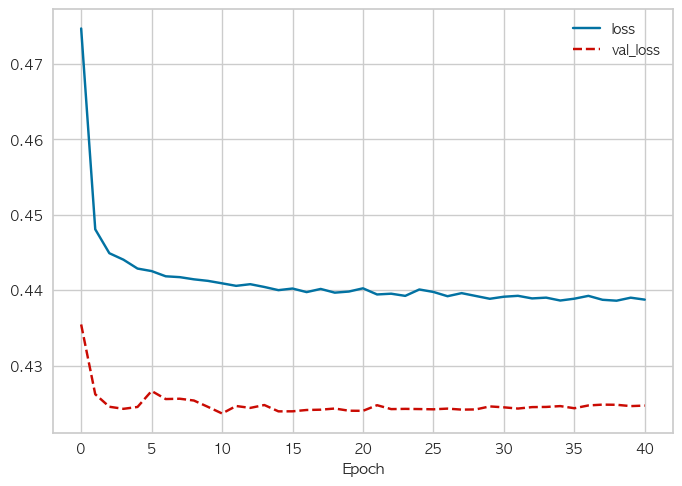

In [43]:
# baseline
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], 'b-', label='loss')
plt.plot(history.history['val_loss'], 'r--', label='val_loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

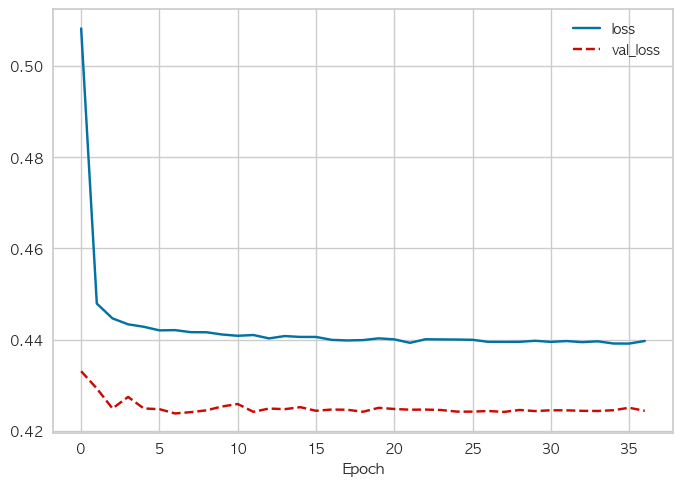

In [338]:
# exp
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], 'b-', label='loss')
plt.plot(history.history['val_loss'], 'r--', label='val_loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [339]:
np.mean(history.history['val_loss'])

0.42498681674132477

**목표** 0.4253
평균 : 0.4249 vs LB : 
평균 : 0.4253 vs LB :  0.4287 

In [340]:
pred = model.predict(test[X.columns].astype('float32'))

343/343 [==============================] - 0s 290us/step


In [321]:
pred

array([[4.146818 ],
       [3.8571382],
       [4.9761863],
       ...,
       [4.6626234],
       [4.6401467],
       [4.4743724]], dtype=float32)

In [341]:
ss['ECLO'] = pred
path = "./light_child_only_도로형태분리.csv"
ss.to_csv(path,index=False)

In [290]:
API = "d2663933ca592bffe5b2e5bfc72c9bc47748168183ea64c6e480c49dbd05250a"

In [323]:
from dacon_submit_api import dacon_submit_api

result = dacon_submit_api.post_submission_file(
path, API,
'236193',
'NAMJIN',
path)

{'isSubmitted': True, 'detail': 'Success'}


In [292]:
path

'./light_child_only.csv'